In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/Archive.zip"

!ls

Streaming output truncated to the last 5000 lines.
  inflating: train/PNEUMONIA/person1608_bacteria_4235.jpeg  
  inflating: train/PNEUMONIA/person445_virus_916.jpeg  
  inflating: train/PNEUMONIA/person302_bacteria_1430.jpeg  
  inflating: train/PNEUMONIA/person1188_bacteria_3137.jpeg  
  inflating: train/PNEUMONIA/person353_virus_728.jpeg  
  inflating: train/PNEUMONIA/person348_bacteria_1602.jpeg  
  inflating: train/PNEUMONIA/person1272_bacteria_3232.jpeg  
  inflating: train/PNEUMONIA/person1294_virus_2222.jpeg  
  inflating: train/PNEUMONIA/person3_bacteria_12.jpeg  
  inflating: train/PNEUMONIA/person124_virus_234.jpeg  
  inflating: train/PNEUMONIA/person378_virus_761.jpeg  
  inflating: train/PNEUMONIA/person1478_bacteria_3848.jpeg  
  inflating: train/PNEUMONIA/person1446_bacteria_3740.jpeg  
  inflating: train/PNEUMONIA/person23_bacteria_91.jpeg  
  inflating: train/PNEUMONIA/person294_bacteria_1381.jpeg  
  inflating: train/PNEUMONIA/person462_bacteria_1967.jpeg  
  inflati

In [ ]:
train_path = "/content/train"
val_path = "/content/val"
test_path = "/content/test"

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)

val_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
model = models.Sequential()

# Convolution + Pooling
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Flatten
model.add(layers.Flatten())

# Dense layers
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))  # binary classification



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.9061 - loss: 0.2209 - val_accuracy: 0.7500 - val_loss: 0.4909
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.9574 - loss: 0.1208 - val_accuracy: 0.8750 - val_loss: 0.2400
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 298s 2s/step - accuracy: 0.9707 - loss: 0.0868 - val_accuracy: 0.7500 - val_loss: 0.4393
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.9774 - loss: 0.0676 - val_accuracy: 0.8125 - val_loss: 0.1821
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.9820 - loss: 0.0504 - val_accuracy: 1.0000 - val_loss: 0.0933
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.9879 - loss: 0.0358 - val_accuracy: 0.9375 - val_loss: 0.1364
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.9914 - loss: 0.0236 - val_accuracy: 0.8750 - val_loss: 0.2897
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.9941 - loss: 0.0166 - val_accu

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 710ms/step - accuracy: 0.7644 - loss: 2.0391
Test Accuracy: 0.7644230723381042


In [ ]:
model.save("pneumonia_model.keras")

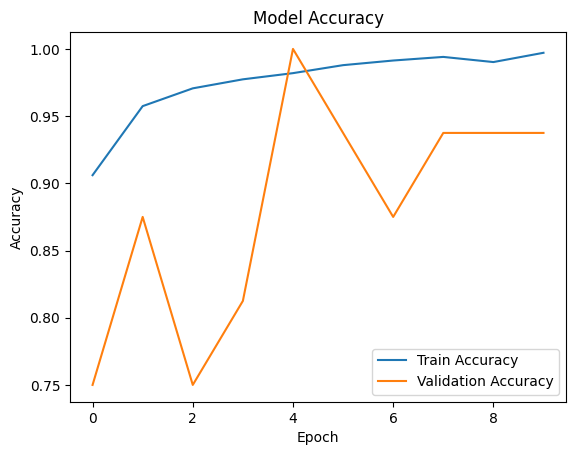

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

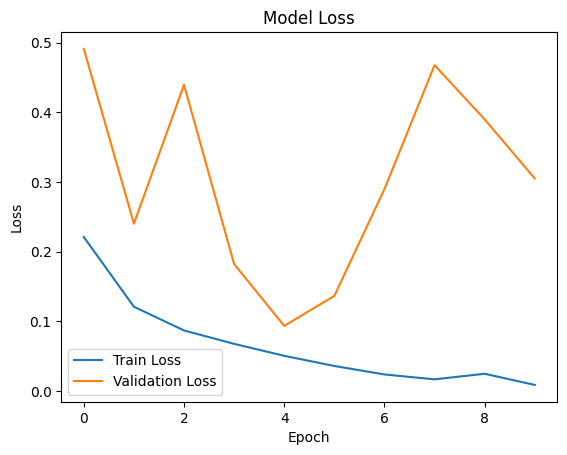

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict
Y_pred = model.predict(test_data)
y_pred = (Y_pred > 0.5).astype(int)

# True labels
y_true = test_data.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 994ms/step
Confusion Matrix:
 [[ 37 197]
 [ 60 330]]

Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.16      0.22       234
           1       0.63      0.85      0.72       390

    accuracy                           0.59       624
   macro avg       0.50      0.50      0.47       624
weighted avg       0.53      0.59      0.53       624



In [ ]:
model.save("pneumonia_model.keras")